# Task 1

### Importing Libraries

In [11]:
import numpy
import torch
import torch.nn as nn
import torch.optim as optim
import types
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE

if torch.cuda.is_available() == True:
    device = 'cuda'
else:
    device = 'cpu'

print(f'device: {device}')

from google.colab import drive
drive.mount('/content/drive')

device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task 1.1

### Dataset Download

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cifar_10_training = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=True, transform=transform, download=True)
cifar_10_validation = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=False, transform=transform, download=True)

train_dataloder = DataLoader(cifar_10_training, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(cifar_10_validation, batch_size=64, shuffle=False)


### Replacing classification layer + training loop

In [ ]:
EPOCHS=5

resnet_pretrained = models.resnet152(weights='DEFAULT')

resnet_pretrained.fc = nn.Linear(in_features=resnet_pretrained.fc.in_features, out_features=10)

for param in resnet_pretrained.parameters():
    param.requires_grad = False

for param in resnet_pretrained.fc.parameters():
    param.requires_grad = True

resnet_pretrained = resnet_pretrained.to(device)

training_loss = []
validation_loss= []

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_pretrained.parameters(), lr=0.01)

for i in range(EPOCHS):
    print(f'epoch: {i}')

    resnet_pretrained.train()
    curr_training_loss = 0

    for image, label in train_dataloder:
        image = image.to(device)
        label = label.to(device)
        optimizer.zero_grad()

        prediction = resnet_pretrained(image)

        curr_loss = loss(prediction, label)
        curr_training_loss += curr_loss.item()

        curr_loss.backward()

        optimizer.step()

    training_loss.append(curr_training_loss/len(train_dataloder))
    print(f'training_loss: {curr_training_loss/len(train_dataloder)}')

    resnet_pretrained.eval()
    curr_validation_loss = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet_pretrained(image)
            curr_loss = loss(prediction, label)

            curr_validation_loss += curr_loss.item()

    validation_loss.append(curr_validation_loss/len(validation_dataloader))
    print(f'validation_loss: {curr_validation_loss/len(validation_dataloader)} \n')



Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:05<00:00, 47.9MB/s]


epoch: 0
training_loss: 1.060699812972637
validation_loss: 0.7353227129028101 

epoch: 1
training_loss: 0.6815424242897716
validation_loss: 0.6354192309318833 

epoch: 2
training_loss: 0.6174031875627425
validation_loss: 0.5962485261024184 

epoch: 3
training_loss: 0.5860998574501414
validation_loss: 0.5663615026671416 

epoch: 4
training_loss: 0.5609540276210326
validation_loss: 0.5509711999422425 



### Visualization for Task 1.1

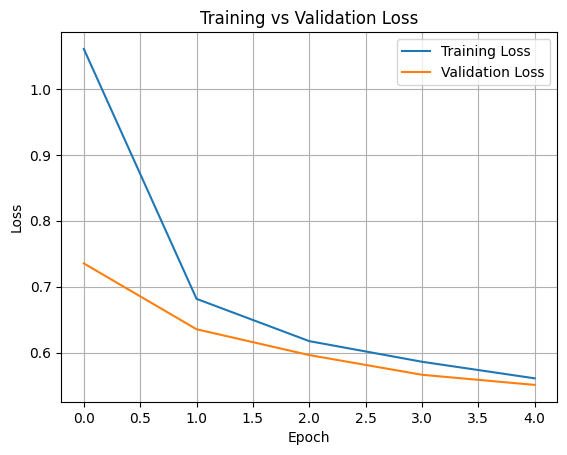

In [ ]:
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.show()

# Task 1.2

### Downloading dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cifar_10_training = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=True, transform=transform, download=True)
cifar_10_validation = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=False, transform=transform, download=True)

train_dataloder = DataLoader(cifar_10_training, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(cifar_10_validation, batch_size=64, shuffle=False)

### Training while disabling residual connections

In [ ]:
def replace_block(block, x):
    return block.relu(block.bn3(block.conv3(block.relu(block.bn2(block.conv2(block.relu(block.bn1(block.conv1(x)))))))))

EPOCHS=5

resnet_pretrained = models.resnet152(weights='DEFAULT')

resnet_pretrained.fc = nn.Linear(in_features=resnet_pretrained.fc.in_features, out_features=10)

for param in resnet_pretrained.parameters():
    param.requires_grad = False

for param in resnet_pretrained.fc.parameters():
    param.requires_grad = True

#replacing blocks with no skip connection
block1 = resnet_pretrained.layer2[2]
block2 = resnet_pretrained.layer3[3]
block3 = resnet_pretrained.layer4[1]
block4 = resnet_pretrained.layer4[2]

block1.forward = types.MethodType(replace_block, block1)
block2.forward = types.MethodType(replace_block, block2)
block3.forward = types.MethodType(replace_block, block3)
block4.forward = types.MethodType(replace_block, block4)
#replacing blocks with no skip connection

resnet_pretrained = resnet_pretrained.to(device)

training_loss_skip = []
validation_loss_skip = []
training_accuracy_skip = []
validation_accuracy_skip = []

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_pretrained.parameters(), lr=0.01)

for i in range(EPOCHS):
    print(f'epoch: {i} \n')

    resnet_pretrained.train()
    curr_training_loss = 0
    curr_training_accuracy = 0

    for image, label in train_dataloder:
        image = image.to(device)
        label = label.to(device)
        optimizer.zero_grad()

        prediction = resnet_pretrained(image)
        predicted_label = prediction.argmax(dim=1)

        curr_loss = loss(prediction, label)

        curr_training_loss += curr_loss.item()
        curr_training_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

        curr_loss.backward()

        optimizer.step()

    training_loss_skip.append(curr_training_loss/len(train_dataloder))
    training_accuracy_skip.append((curr_training_accuracy/len(train_dataloder))*100)
    print(f'training loss with no residual connections: {curr_training_loss/len(train_dataloder)}')
    print(f'training accuracy with no residual connections: {(curr_training_accuracy/len(train_dataloder))*100}% \n')

    resnet_pretrained.eval()
    curr_validation_loss = 0
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            prediction = resnet_pretrained(image)
            predicted_label = prediction.argmax(dim=1)

            curr_loss = loss(prediction, label)

            curr_validation_loss += curr_loss.item()
            curr_validation_accuracy += accuracy_score(label.cpu().numpy(), predicted_label.cpu().numpy())

    validation_loss_skip.append(curr_validation_loss/len(validation_dataloader))
    validation_accuracy_skip.append((curr_validation_accuracy/len(validation_dataloader))*100)
    print(f'validation loss with no residual connections: {curr_validation_loss/len(validation_dataloader)}')
    print(f'validation accuracy with no residual connections: {(curr_validation_accuracy/len(validation_dataloader))*100}% \n')



epoch: 0 

training loss with no residual connections: 2.3026352474451675
training accuracy with no residual connections: 10.07632672634271% 

validation loss with no residual connections: 2.631963599259686
validation accuracy with no residual connections: 10.171178343949045% 

epoch: 1 

training loss with no residual connections: 2.3024693462244996
training accuracy with no residual connections: 9.986413043478262% 

validation loss with no residual connections: 2.3496565013934094
validation accuracy with no residual connections: 9.96218152866242% 

epoch: 2 

training loss with no residual connections: 2.302352542462556
training accuracy with no residual connections: 10.252157928388748% 

validation loss with no residual connections: 2.4913011569126398
validation accuracy with no residual connections: 10.638933121019107% 

epoch: 3 

training loss with no residual connections: 2.302135262038092
training accuracy with no residual connections: 10.302109974424553% 

validation loss with

### Visualizing Task 1.2

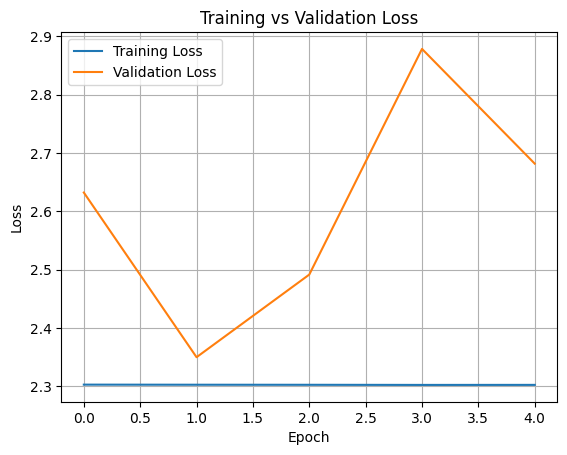

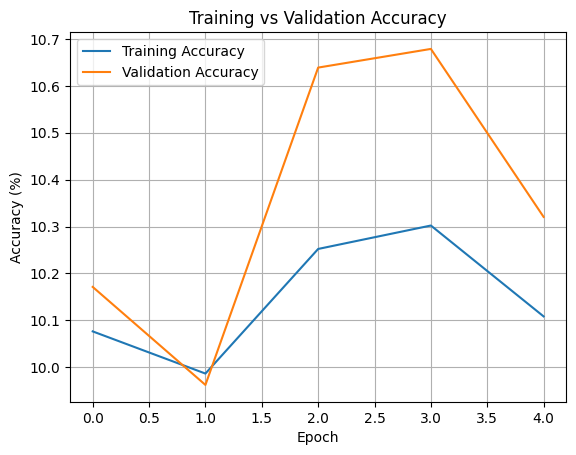

In [ ]:
plt.figure()
plt.plot(training_loss_skip, label='Training Loss')
plt.plot(validation_loss_skip, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.figure()
plt.plot(training_accuracy_skip, label='Training Accuracy')
plt.plot(validation_accuracy_skip, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()



plt.show()

# Task 1.3

### Download CIFAR-10 data

In [12]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cifar_10_training = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=True, transform=transform, download=True)
cifar_10_validation = datasets.CIFAR10(root='/content/drive/MyDrive/datasets', train=False, transform=transform, download=True)

train_dataloder = DataLoader(cifar_10_training, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(cifar_10_validation, batch_size=64, shuffle=False)

### Collecting coordinates using TSNE

In [30]:
layer1_features = []
layer3_features = []
layer4_features = []
labels = []

def hook_collect_layer1(module, input, output):
    layer1_features.append(output.detach().cpu())

def hook_collect_layer3(module, input, output):
    layer3_features.append(output.detach().cpu())

def hook_collect_layer4(module, input, output):
    layer4_features.append(output.detach().cpu())

resnet_pretrained = models.resnet152(weights='DEFAULT').to(device)
resnet_pretrained.layer1.register_forward_hook(hook_collect_layer1)
resnet_pretrained.layer3.register_forward_hook(hook_collect_layer3)
resnet_pretrained.layer4.register_forward_hook(hook_collect_layer4)

curr_batch = 0

with torch.no_grad():
  for image, label in train_dataloder:
      image = image.to(device)
      label = label.to(device)

      if curr_batch == 5:
          break

      prediction = resnet_pretrained(image)
      labels.append(label)

      curr_batch += 1

layer1_tensor = torch.cat(layer1_features, dim=0)
layer3_tensor = torch.cat(layer3_features, dim=0)
layer4_tensor = torch.cat(layer4_features, dim=0)
labels_tensor = torch.cat(labels, dim=0)

layer1_tensor_flattened = layer1_tensor.mean(dim=(2,3))
layer3_tensor_flattened = layer3_tensor.mean(dim=(2,3))
layer4_tensor_flattened = layer4_tensor.mean(dim=(2,3))

tsne = TSNE(perplexity=10, random_state=42)

layer1_coordinates = tsne.fit_transform(layer1_tensor_flattened)
layer3_coordinates = tsne.fit_transform(layer3_tensor_flattened)
layer4_coordinates = tsne.fit_transform(layer4_tensor_flattened)
labels = labels_tensor.cpu().numpy()


### Visualizing early, middle and late features

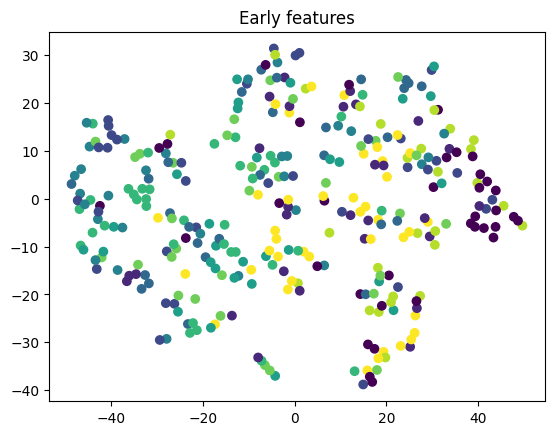

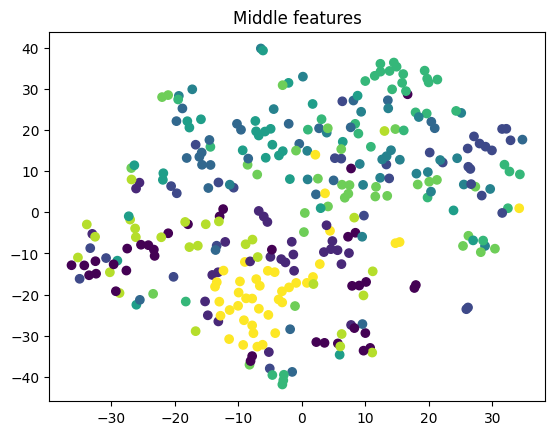

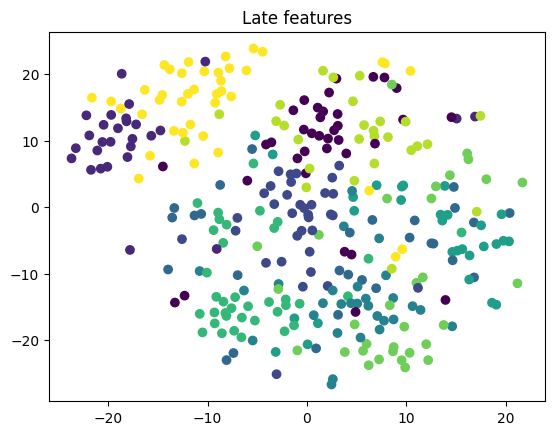

In [31]:
plt.figure()
plt.scatter(layer1_coordinates[:,0], layer1_coordinates[:,1], c=labels)
plt.title('Early features')

plt.figure()
plt.scatter(layer3_coordinates[:,0], layer3_coordinates[:,1], c=labels)
plt.title('Middle features')

plt.figure()
plt.scatter(layer4_coordinates[:,0], layer4_coordinates[:,1], c=labels)
plt.title('Late features')
plt.show()

